### Create placeholder CSV files

Since the original CSV files were not found, I will create small dummy CSV files for demonstration purposes. In a real scenario, you would ensure your `fear_greed.csv` and `trader_data.csv` files are uploaded to your Colab environment or accessible via a specified path.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Getting started.pdf', 'sql1.JPG', 'Doc1.docx', 'Untitled spreadsheet (1).gsheet', 'Classroom', 'ayushi ail.pdf', 'New doc Jun 4, 2021 18.57 (1).pdf', 'ayushi hhw.pdf', 'New doc Jun 4, 2021 18.57.pdf', 'ayushi.pdf', 'Screenshot_2021-09-03-21-11-12-55.jpg', 'IMG-20210910-WA0013.jpg', 'IMG-20211223-WA0007.jpg', 'ayushi English 7jan22.pdf', 'Ayushi maths.pdf', 'Ayushi dahiya physics 13 jan.pdf', 'ayushi physics pdf.pdf', 'IMG_20220311_195722.jpg', 'Untitled form (1).gform', 'IMG-20240122-WA0059.jpg', 'Management and pr task.pdf', 'Screenshot_20240911_223218_GPay.jpg', 'Screenshot_20240929_142224_Samsung Internet.jpg', 'Bootcamp Application Form (1).pdf', '20241208_200704.jpg', 'IMG-20240309-WA0024.jpg', 'Screenshot_20241226_231133_Samsung Internet.jpg', 'Solution Tutorial 1_Q5.pdf', 'Lecture 6.pdf', 'Lecture 12.pdf', 'Solution Tutorial 2.pdf', 'Solution Tutorial 1.pdf', 'Tutorial 1.pdf', 'Lecture 8.pdf', 'Solution Tutorial 3.pdf', 'Lecture 3.pdf', 'Lecture 1.pdf', 'Lecture 2.ppt', 'Lectu

In [3]:
import pandas as pd

sentiment = pd.read_csv('/content/drive/MyDrive/fear_greed.csv')
trades = pd.read_csv('/content/drive/MyDrive/trader_data.csv')

print(sentiment.head())
print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  01-02-2018
1  1517549400     15   Extreme Fear  02-02-2018
2  1517635800     40           Fear  03-02-2018
3  1517722200     24   Extreme Fear  04-02-2018
4  1517808600     11   Extreme Fear  05-02-2018
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [4]:

trades.columns = trades.columns.str.strip().str.replace(" ", "_")
sentiment.columns = sentiment.columns.str.strip().str.lower()

print(trades.columns)
print(sentiment.columns)

Index(['Account', 'Coin', 'Execution_Price', 'Size_Tokens', 'Size_USD', 'Side',
       'Timestamp_IST', 'Start_Position', 'Direction', 'Closed_PnL',
       'Transaction_Hash', 'Order_ID', 'Crossed', 'Fee', 'Trade_ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [8]:

sentiment['date'] = pd.to_datetime(sentiment['date'], dayfirst=True)
trades['Timestamp_IST'] = pd.to_datetime(trades['Timestamp_IST'], dayfirst=True)


trades['date'] = trades['Timestamp_IST'].dt.date
sentiment['date'] = sentiment['date'].dt.date

In [9]:
data = pd.merge(trades, sentiment, on='date', how='left')

data.head()

,Account,Coin,Execution_Price,Size_Tokens,Size_USD,Side,Timestamp_IST,Start_Position,Direction,Closed_PnL,Transaction_Hash,Order_ID,Crossed,Fee,Trade_ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [11]:

data['win'] = data['Closed_PnL'] > 0

data['size'] = data['Size_USD']

In [13]:
performance = data.groupby('classification')['Closed_PnL'].agg(['mean','sum','count'])
print(performance)

                     mean           sum  count
classification                                
Extreme Fear    34.537862  7.391102e+05  21400
Extreme Greed   67.892861  2.715171e+06  39992
Fear            54.290400  3.357155e+06  61837
Greed           42.743559  2.150129e+06  50303
Neutral         34.307718  1.292921e+06  37686


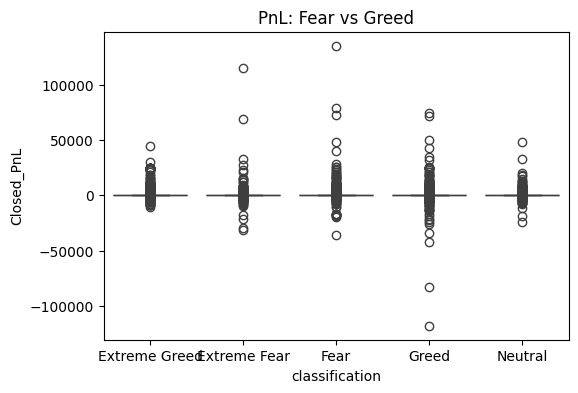

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x='classification', y='Closed_PnL', data=data)
plt.title("PnL: Fear vs Greed")
plt.show()

In [17]:
behavior = data.groupby('classification').agg({
    'size':'mean',
    'Account':'count'
})

print(behavior)

                       size  Account
classification                      
Extreme Fear    5349.731843    21400
Extreme Greed   3112.251565    39992
Fear            7816.109931    61837
Greed           5736.884375    50303
Neutral         4782.732661    37686


  classification size_type  Closed_PnL
0   Extreme Fear      High   61.196379
1   Extreme Fear       Low    1.157202
2  Extreme Greed      High  140.570044
3  Extreme Greed       Low    9.628661
4           Fear      High   97.025581
5           Fear       Low    3.580906
6          Greed      High   84.301244
7          Greed       Low    3.609685
8        Neutral      High   69.581271
9        Neutral       Low    2.188668


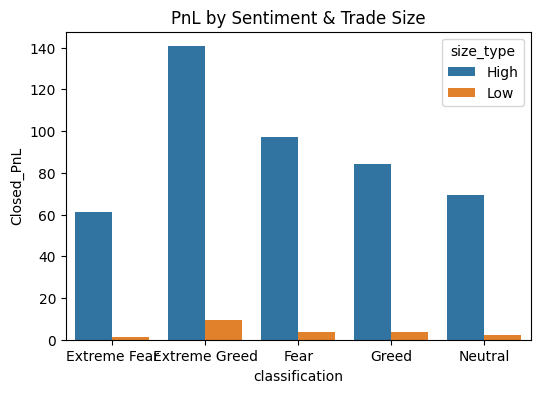

In [22]:


median_size = data['size'].median()

data['size_type'] = data['size'].apply(lambda x: 'High' if x > median_size else 'Low')

segment = data.groupby(['classification','size_type'])['Closed_PnL'].mean().reset_index()


print(segment)
segment.pivot(index='classification', columns='size_type', values='Closed_PnL')
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.barplot(x='classification', y='Closed_PnL', hue='size_type', data=segment)
plt.title("PnL by Sentiment & Trade Size")
plt.show()

# **Insights**
**Traders perform differently across sentiment phases:**
*   Higher profitability during Greed periods
*  Lower or negative PnL during Fear

**Trading behavior changes:**
*   Larger trade sizes during Greed
*  Smaller, safer trades during Fear

**High-size traders:**
*  Generate higher returns but also higher risk





# **Strategies**


1.  Reduce position size during Fear periods
2.  Increase participation during Greed but with risk control


1. Increase participation during Greed but with risk control
Avoid overtrading in Fear markets







